# Trabalho Computacional 1: Equação do Calor unidimensional em regime estacionário
## PPG-Biometria
### Disciplina: Matemática Aplicada
### Professor: Fernando Luiz Pio dos Santos
### Aluno: Vitor Eduardo Girotto Barelli

## Objetivo

Resolver numericamente a equação do calor com regime estacionário, unidimensional, discretizada de forma implícita pelo método de Diferenças Finitas, conforme aula. Obter a solução analítica e comparar com a solução numérica encontrada, exibindo num gráfico. Observação: Escolher livremente os valores dos parâmetros da equação, os parâmetros computacionais e as condições de contorno e iniciais.

---

## Problema considerado

Considera-se a equação do calor unidimensional:

\[
\frac{\partial T}{\partial t}=\alpha \frac{\partial^2 T}{\partial x^2},
\qquad 0<x<L,\; t>0
\]

com as seguintes condições de contorno de Dirichlet:

\[
T(0,t)=100
\qquad\text{e}\qquad
T(L,t)=20
\]

e condição inicial:

\[
T(x,0)=0
\]

Neste trabalho, adotam-se:

- \(L=1\): comprimento da barra;
- \(\alpha=1\): difusividade térmica;
- extremidade esquerda mantida a \(100\);
- extremidade direita mantida a \(20\).

A solução numérica será obtida por avanço temporal implícito até que o sistema atinja o **regime estacionário**.

## Solução analítica no regime estacionário

No regime estacionário, a temperatura deixa de depender do tempo. Logo,

\[
\frac{\partial T}{\partial t}=0
\]

e a equação se reduz a

\[
\frac{d^2T}{dx^2}=0
\]

Integrando duas vezes,

\[
T(x)=C_1x+C_2
\]

Aplicando as condições de contorno:

\[
T(0)=100 \Rightarrow C_2=100
\]

\[
T(1)=20 \Rightarrow C_1+100=20 \Rightarrow C_1=-80
\]

Portanto, a solução analítica estacionária é dada por:

\[
T_{\mathrm{analítica}}(x)=100-80x
\]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Discretização implícita por Diferenças Finitas

Discretizando o espaço e o tempo, escreve-se:

- \(x_i=i\Delta x\)
- \(t^n=n\Delta t\)

A discretização implícita da equação do calor é:

\[
\frac{T_i^{n+1}-T_i^n}{\Delta t}
=
\alpha
\frac{T_{i+1}^{n+1}-2T_i^{n+1}+T_{i-1}^{n+1}}{\Delta x^2}
\]

Definindo

\[
r=\frac{\alpha \Delta t}{\Delta x^2}
\]

obtém-se, para os pontos internos da malha:

\[
-r\,T_{i-1}^{n+1} + (1+2r)\,T_i^{n+1} - r\,T_{i+1}^{n+1} = T_i^n
\]

Em cada passo no tempo, isso gera um sistema linear tridiagonal da forma:

\[
A\,T^{n+1}=b
\]

que é resolvido numericamente até que a solução pare de variar significativamente entre duas iterações consecutivas.

In [2]:
# ============================================================
# Parâmetros físicos e numéricos
# ============================================================
L = 1.0
alpha = 1.0

T_esq = 100.0
T_dir = 20.0

Nx = 21                  # número total de pontos da malha
dx = L / (Nx - 1)

dt = 0.001               # passo temporal
r = alpha * dt / dx**2

tol = 1e-8               # critério de parada para regime estacionário
max_iter = 50000

x = np.linspace(0, L, Nx)

print(f"Número de pontos da malha: {Nx}")
print(f"dx = {dx:.5f}")
print(f"dt = {dt:.5f}")
print(f"r = {r:.5f}")

Número de pontos da malha: 21
dx = 0.05000
dt = 0.00100
r = 0.40000


In [3]:
# ============================================================
# Condição inicial
# ============================================================
T = np.zeros(Nx)
T[0] = T_esq
T[-1] = T_dir

print("Temperatura inicial:")
print(T)

Temperatura inicial:
[100.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  20.]


In [4]:
# ============================================================
# Montagem da matriz do método implícito
# ============================================================
Nint = Nx - 2
A = np.zeros((Nint, Nint))

for i in range(Nint):
    A[i, i] = 1 + 2 * r
    if i > 0:
        A[i, i - 1] = -r
    if i < Nint - 1:
        A[i, i + 1] = -r

print("Matriz A do sistema implícito:")
print(A)

Matriz A do sistema implícito:
[[ 1.8 -0.4  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [-0.4  1.8 -0.4  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.  -0.4  1.8 -0.4  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.4  1.8 -0.4  0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.4  1.8 -0.4  0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.4  1.8 -0.4  0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.4  1.8 -0.4  0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -0.4  1.8 -0.4  0.   0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.4  1.8 -0.4  0.   0.   0.   0.
   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.  -0.4  1.8 -0.4  0.   0.   0.
   0.  

In [5]:
# ============================================================
# Iteração temporal até atingir o regime estacionário
# ============================================================
historico_erro_iteracao = []
historico_erro_max_analitico = []

T_analitica = 100 - 80 * x

for n in range(max_iter):
    T_old = T.copy()

    # lado direito do sistema
    b = T_old[1:-1].copy()

    # incorporação das condições de contorno
    b[0] += r * T_esq
    b[-1] += r * T_dir

    # resolução do sistema linear
    T[1:-1] = np.linalg.solve(A, b)

    # reaplicação das condições de contorno
    T[0] = T_esq
    T[-1] = T_dir

    # erros
    erro_iteracao = np.max(np.abs(T - T_old))
    erro_max_analitico = np.max(np.abs(T - T_analitica))

    historico_erro_iteracao.append(erro_iteracao)
    historico_erro_max_analitico.append(erro_max_analitico)

    if erro_iteracao < tol:
        print(f"Regime estacionário atingido na iteração {n + 1}")
        break
else:
    print("O número máximo de iterações foi atingido antes da convergência.")

print("\nSolução numérica final:")
print(T)

Regime estacionário atingido na iteração 1851

Solução numérica final:
[100.          95.99999984  91.99999969  87.99999954  83.99999941
  79.99999929  75.99999918  71.9999991   67.99999904  63.999999
  59.99999899  55.999999    51.99999904  47.9999991   43.99999918
  39.99999929  35.99999941  31.99999954  27.99999969  23.99999984
  20.        ]


In [6]:
# ============================================================
# Solução analítica e erros
# ============================================================
T_analitica = 100 - 80 * x

erro_absoluto = np.abs(T - T_analitica)
erro_maximo = np.max(erro_absoluto)

print("Solução analítica:")
print(T_analitica)

print("\nErro absoluto em cada ponto:")
print(erro_absoluto)

print(f"\nErro máximo global = {erro_maximo:.10e}")

Solução analítica:
[100.  96.  92.  88.  84.  80.  76.  72.  68.  64.  60.  56.  52.  48.
  44.  40.  36.  32.  28.  24.  20.]

Erro absoluto em cada ponto:
[0.00000000e+00 1.57604546e-07 3.11328350e-07 4.57386207e-07
 5.92181735e-07 7.12395732e-07 8.15068205e-07 8.97670958e-07
 9.58170091e-07 9.95075901e-07 1.00747965e-06 9.95075887e-07
 9.58170070e-07 8.97670937e-07 8.15068141e-07 7.12395682e-07
 5.92181671e-07 4.57386189e-07 3.11328332e-07 1.57604536e-07
 0.00000000e+00]

Erro máximo global = 1.0074796464e-06


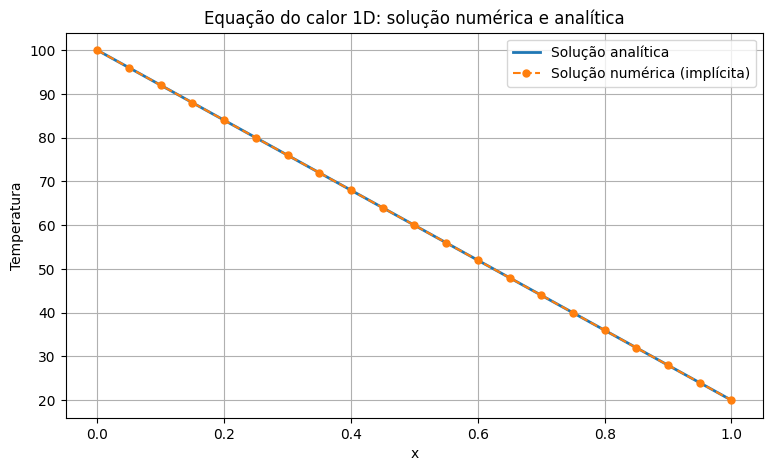

In [7]:
# ============================================================
# Gráfico: solução numérica versus solução analítica
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(x, T_analitica, label='Solução analítica', linewidth=2)
plt.plot(x, T, 'o--', label='Solução numérica (implícita)', markersize=5)
plt.xlabel('x')
plt.ylabel('Temperatura')
plt.title('Equação do calor 1D: solução numérica e analítica')
plt.grid(True)
plt.legend()
plt.show()

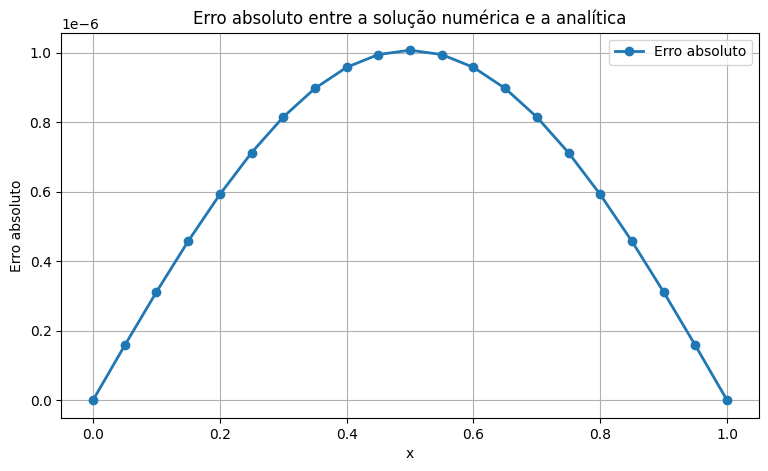

In [8]:
# ============================================================
# Gráfico do erro absoluto ao longo da barra
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(x, erro_absoluto, 'o-', linewidth=2, label='Erro absoluto')
plt.xlabel('x')
plt.ylabel('Erro absoluto')
plt.title('Erro absoluto entre a solução numérica e a analítica')
plt.grid(True)
plt.legend()
plt.show()

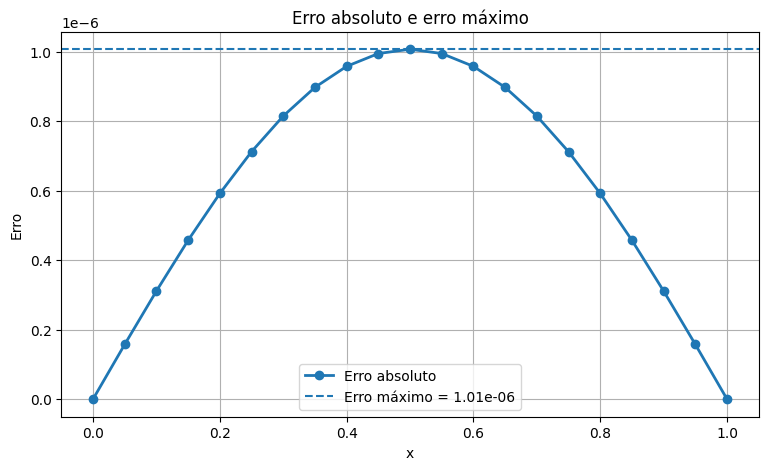

In [9]:
# ============================================================
# Gráfico do erro absoluto com destaque para o erro máximo
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(x, erro_absoluto, 'o-', linewidth=2, label='Erro absoluto')
plt.axhline(erro_maximo, linestyle='--', label=f'Erro máximo = {erro_maximo:.2e}')
plt.xlabel('x')
plt.ylabel('Erro')
plt.title('Erro absoluto e erro máximo')
plt.grid(True)
plt.legend()
plt.show()

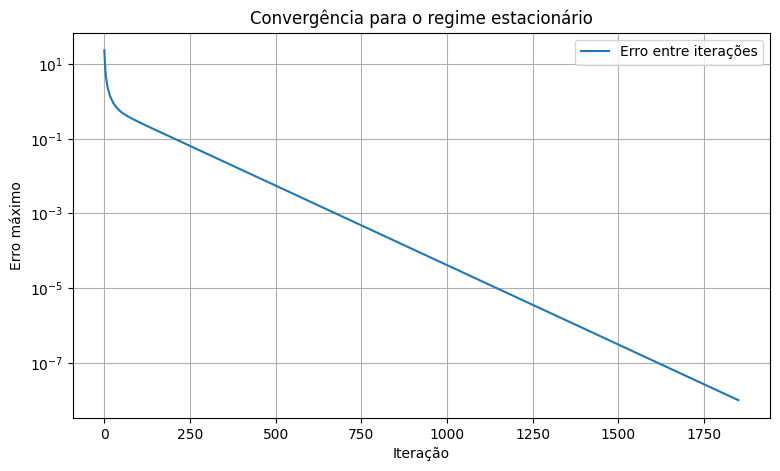

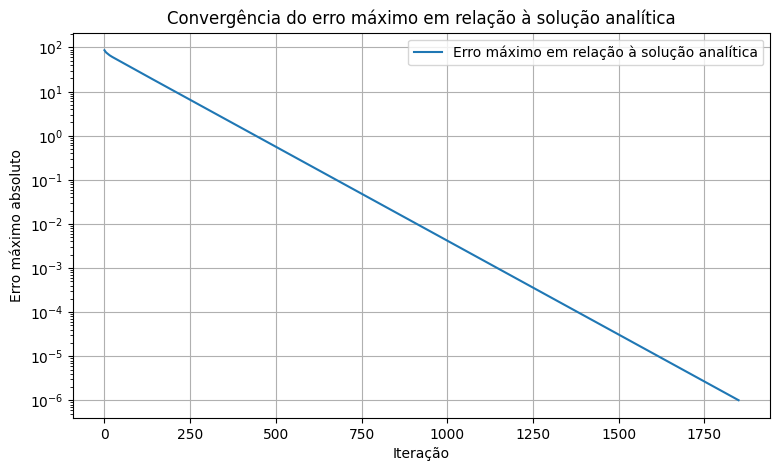

In [10]:
# ============================================================
# Gráfico da convergência do método
# ============================================================
plt.figure(figsize=(9, 5))
plt.semilogy(historico_erro_iteracao, label='Erro entre iterações')
plt.xlabel('Iteração')
plt.ylabel('Erro máximo')
plt.title('Convergência para o regime estacionário')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.semilogy(historico_erro_max_analitico, label='Erro máximo em relação à solução analítica')
plt.xlabel('Iteração')
plt.ylabel('Erro máximo absoluto')
plt.title('Convergência do erro máximo em relação à solução analítica')
plt.grid(True)
plt.legend()
plt.show()

## Conclusão

A equação do calor unidimensional foi resolvida numericamente por meio do método implícito de Diferenças Finitas. A cada passo temporal, foi resolvido um sistema linear correspondente à discretização implícita da equação, até que a solução convergisse para o regime estacionário.

A solução analítica estacionária do problema é a função linear

\[
T(x)=100-80x
\]

A comparação gráfica entre a solução numérica final e a solução analítica mostrou concordância praticamente total. O erro absoluto foi muito pequeno em toda a malha, e o erro máximo global permaneceu em ordem numérica baixa, o que confirma a consistência do método aplicado.

OBS: Vale lembrar que essa concordância quase nunca acontece, só ocorreu nesse caso, pois é um problema muito especial, afinal:

- A EDO tem solução linear e o método numerico escolhido reproduz exatamente a mesma solução na malha!
- A malha é uniforme!
- Os coeficientes não são variáveis!
- etc...
  
OBS2: Se não estivessemos analisando esse caso muito especial, haveria um erro de discretização real e considerável!